In [2]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
# Cell 2: Load Dataset
# NSL-KDD column names
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty_level'
]

# Load training data
df_train = pd.read_csv('../data/raw/KDDTrain+.txt', names=column_names)
df_test = pd.read_csv('../data/raw/KDDTest+.txt', names=column_names)

print(f"✅ Training data shape: {df_train.shape}")
print(f"✅ Test data shape: {df_test.shape}")

✅ Training data shape: (125973, 43)
✅ Test data shape: (22544, 43)


In [4]:
# Cell 3: Basic Data Exploration
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Display first few rows
print("\n📋 First 5 rows:")
print(df_train.head())

# Data info
print("\n📊 Dataset Info:")
print(df_train.info())

# Basic statistics
print("\n📈 Statistical Summary:")
print(df_train.describe())


DATASET OVERVIEW

📋 First 5 rows:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  \
0               0       0    0                  0          0                0   
1               0       0    0                  0          0                0   
2               0       0    0                  0          0                0   
3               0       0    0                  0          1                0   
4               0       0    0                  0          1                0   

   root_shell  su_attempted  num_root  num_fil

In [5]:
# Cell 4: Check Missing Values
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

missing_values = df_train.isnull().sum()
print(f"\nTotal missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("\nColumns with missing values:")
    print(missing_values[missing_values > 0])
else:
    print("\n✅ No missing values found!")


MISSING VALUES CHECK

Total missing values: 0

✅ No missing values found!


ATTACK TYPE DISTRIBUTION

Attack type counts:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
Name: count, dtype: int64


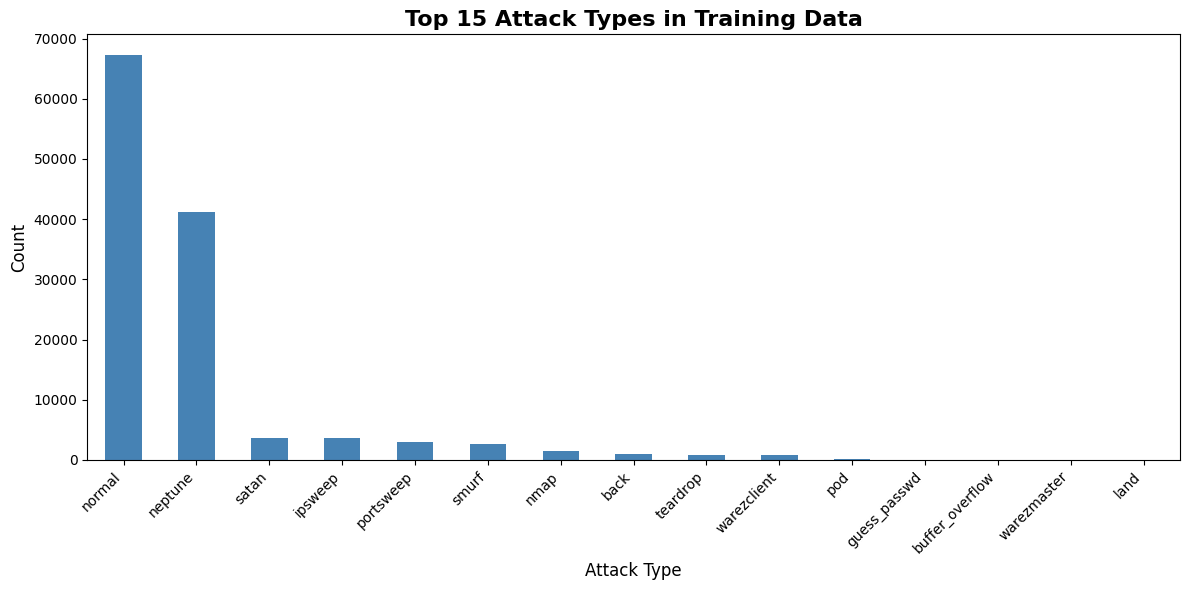


Percentage distribution:
attack_type
normal         53.458281
neptune        32.716534
satan           2.883951
ipsweep         2.856961
portsweep       2.326689
smurf           2.100450
nmap            1.185175
back            0.758893
teardrop        0.708088
warezclient     0.706501
Name: count, dtype: float64


In [6]:
# Cell 5: Attack Type Distribution
print("=" * 60)
print("ATTACK TYPE DISTRIBUTION")
print("=" * 60)

# Count attack types
attack_counts = df_train['attack_type'].value_counts()
print("\nAttack type counts:")
print(attack_counts.head(20))

# Visualize
plt.figure(figsize=(12, 6))
attack_counts.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Attack Types in Training Data', fontsize=16, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate percentages
print("\nPercentage distribution:")
print((attack_counts / len(df_train) * 100).head(10))


NORMAL VS ATTACK

Normal traffic: 67343 (53.46%)
Attack traffic: 58630 (46.54%)


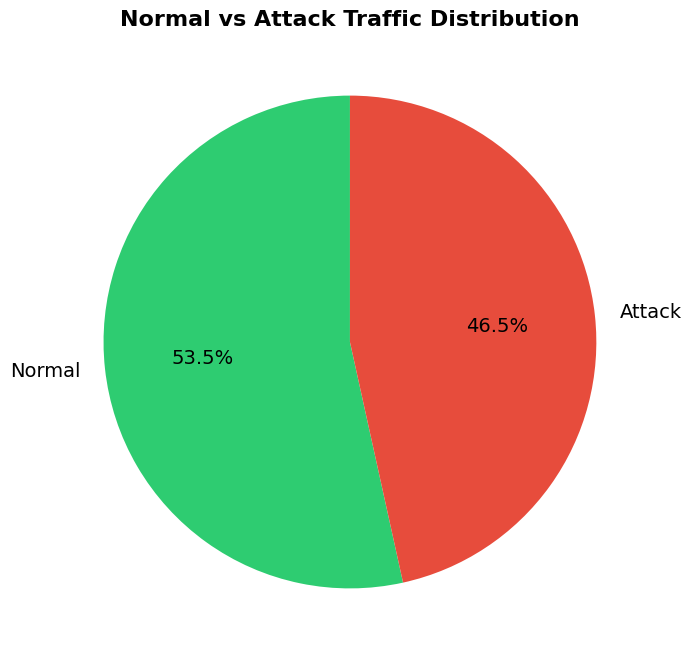

In [7]:
# Cell 6: Normal vs Attack Classification
print("=" * 60)
print("NORMAL VS ATTACK")
print("=" * 60)

# Create binary classification
df_train['is_attack'] = df_train['attack_type'].apply(lambda x: 0 if x == 'normal' else 1)

attack_distribution = df_train['is_attack'].value_counts()
print(f"\nNormal traffic: {attack_distribution[0]} ({attack_distribution[0]/len(df_train)*100:.2f}%)")
print(f"Attack traffic: {attack_distribution[1]} ({attack_distribution[1]/len(df_train)*100:.2f}%)")

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(attack_distribution, labels=['Normal', 'Attack'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 14})
plt.title('Normal vs Attack Traffic Distribution', fontsize=16, fontweight='bold')
plt.show()


PROTOCOL TYPE ANALYSIS

Protocol distribution:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


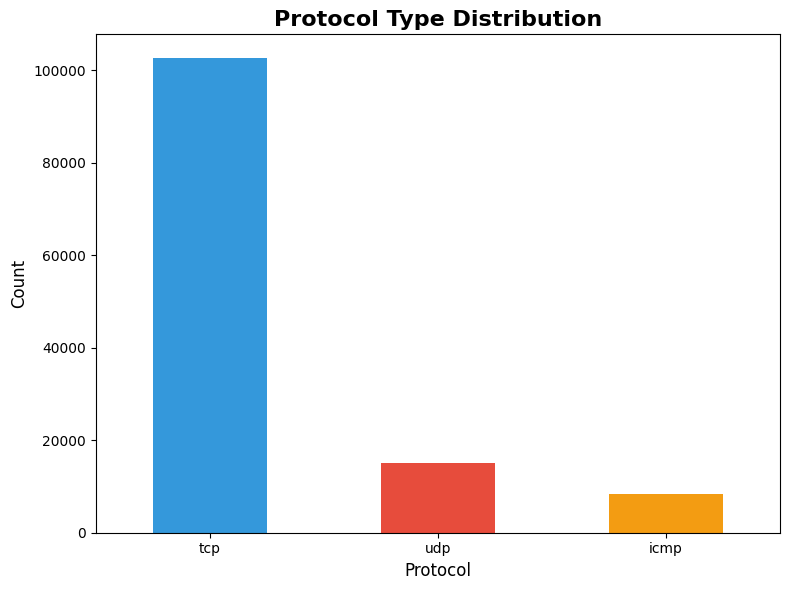

In [8]:
# Cell 7: Protocol Type Analysis
print("=" * 60)
print("PROTOCOL TYPE ANALYSIS")
print("=" * 60)

protocol_counts = df_train['protocol_type'].value_counts()
print("\nProtocol distribution:")
print(protocol_counts)

# Visualize
plt.figure(figsize=(8, 6))
protocol_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#f39c12'])
plt.title('Protocol Type Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Protocol', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


FEATURE CORRELATION

Top 15 features correlated with attacks:
is_attack                      1.000000
dst_host_srv_serror_rate       0.654985
dst_host_serror_rate           0.651842
serror_rate                    0.650652
srv_serror_rate                0.648289
count                          0.576444
dst_host_count                 0.375052
srv_rerror_rate                0.253504
dst_host_srv_rerror_rate       0.253430
rerror_rate                    0.253397
dst_host_rerror_rate           0.252563
dst_host_diff_srv_rate         0.242898
diff_srv_rate                  0.203660
wrong_fragment                 0.095905
dst_host_same_src_port_rate    0.092444
dtype: float64


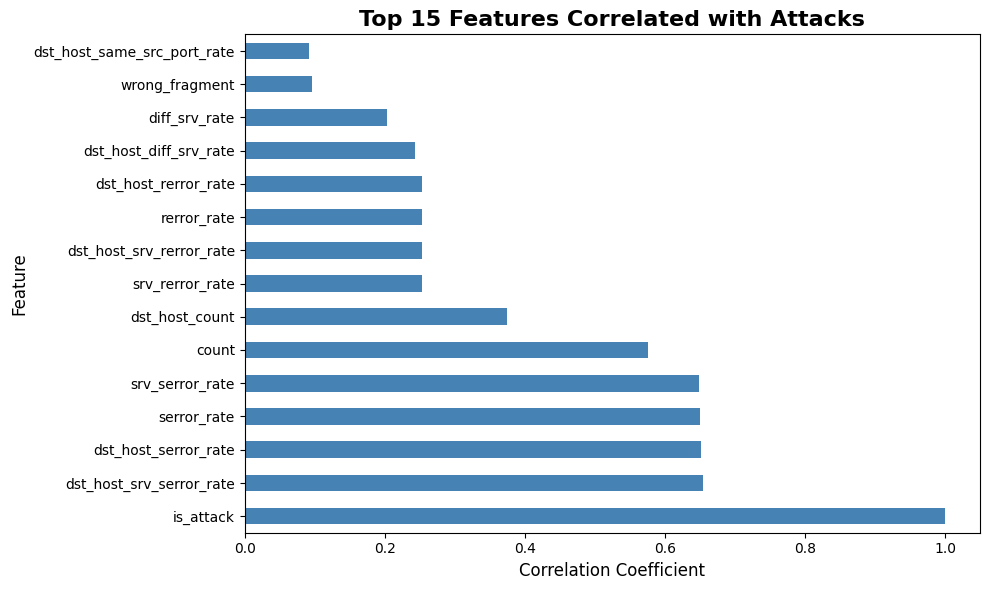

In [9]:
# Cell 8: Feature Correlation Analysis
print("=" * 60)
print("FEATURE CORRELATION")
print("=" * 60)

# Select numerical features for correlation
numerical_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('difficulty_level')  # Remove if present

# Calculate correlation with attack type
correlation = df_train[numerical_features].corrwith(df_train['is_attack']).sort_values(ascending=False)
print("\nTop 15 features correlated with attacks:")
print(correlation.head(15))

# Visualize top correlations
plt.figure(figsize=(10, 6))
correlation.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Correlated with Attacks', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()


KEY FEATURE DISTRIBUTIONS


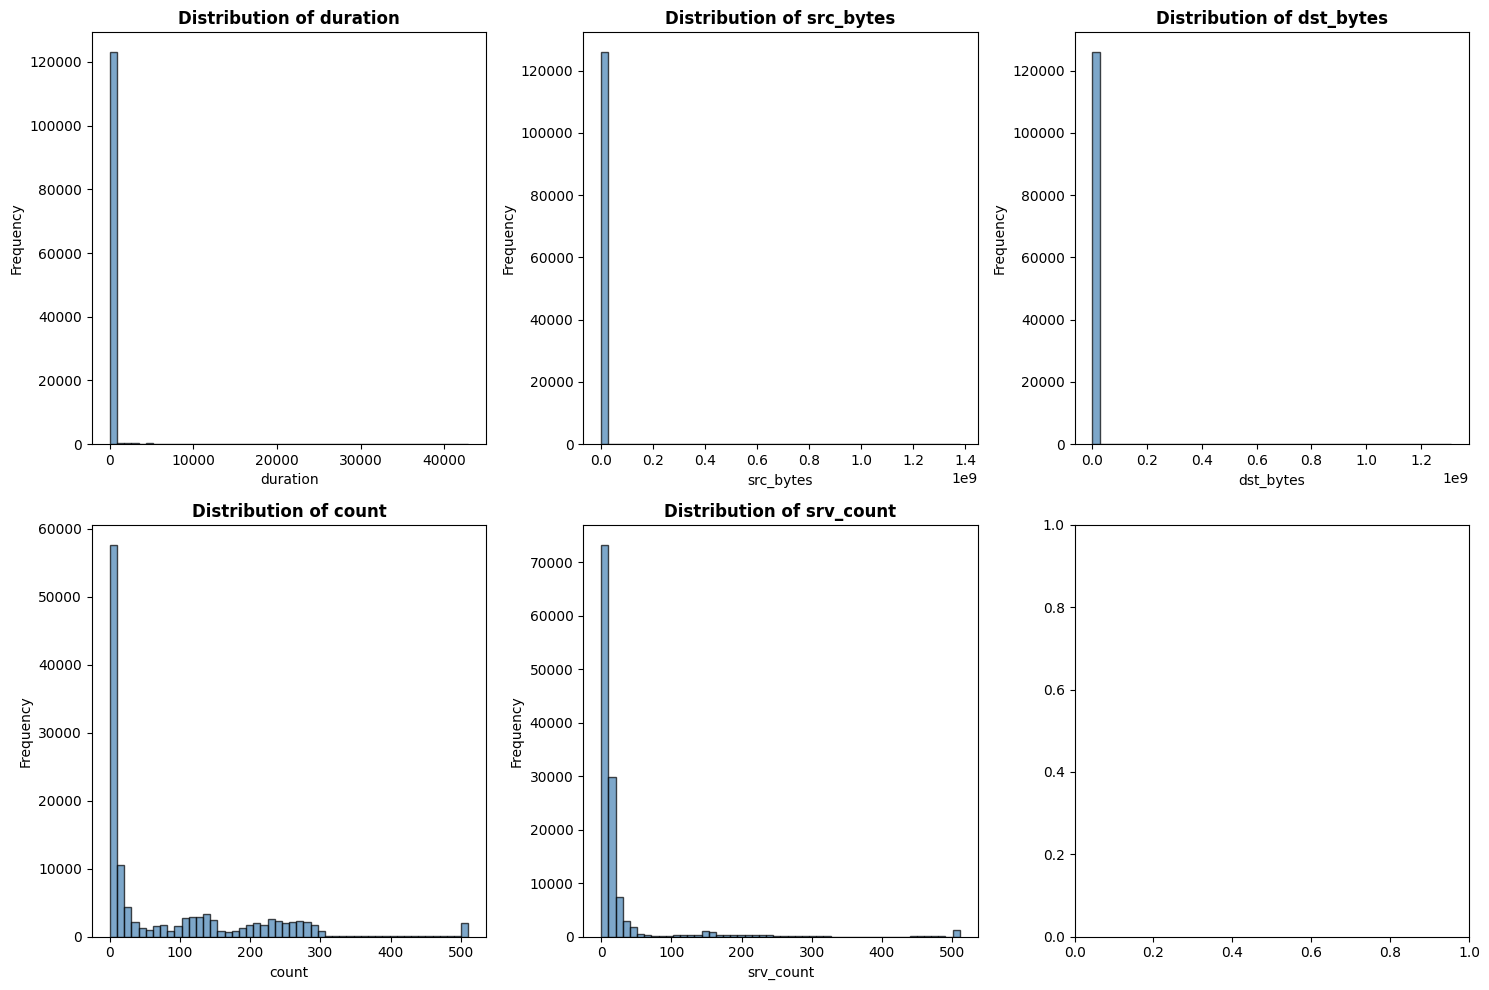

In [10]:
# Cell 9: Feature Distribution Visualizations
print("=" * 60)
print("KEY FEATURE DISTRIBUTIONS")
print("=" * 60)

# Select key features to visualize
key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df_train[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [11]:
# Cell 10: Summary and Insights
print("=" * 60)
print("SUMMARY & KEY INSIGHTS")
print("=" * 60)

print(f"""
✅ Dataset loaded successfully
   - Training samples: {len(df_train):,}
   - Test samples: {len(df_test):,}
   - Total features: {df_train.shape[1]}

✅ Data quality
   - Missing values: {df_train.isnull().sum().sum()}
   - Duplicate rows: {df_train.duplicated().sum()}

✅ Attack distribution
   - Normal traffic: {attack_distribution[0]:,} ({attack_distribution[0]/len(df_train)*100:.1f}%)
   - Attack traffic: {attack_distribution[1]:,} ({attack_distribution[1]/len(df_train)*100:.1f}%)
   - Unique attack types: {df_train['attack_type'].nunique()}

✅ Protocol types: {', '.join(df_train['protocol_type'].unique())}

✅ Next steps:
   1. Feature engineering
   2. Data preprocessing
   3. Model training

📊 EDA Complete! Ready for preprocessing.
""")


SUMMARY & KEY INSIGHTS

✅ Dataset loaded successfully
   - Training samples: 125,973
   - Test samples: 22,544
   - Total features: 44

✅ Data quality
   - Missing values: 0
   - Duplicate rows: 0

✅ Attack distribution
   - Normal traffic: 67,343 (53.5%)
   - Attack traffic: 58,630 (46.5%)
   - Unique attack types: 23

✅ Protocol types: tcp, udp, icmp

✅ Next steps:
   1. Feature engineering
   2. Data preprocessing
   3. Model training

📊 EDA Complete! Ready for preprocessing.

